### Importing libraries 

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Connecting to the database 

In [122]:
import sqlite3 
connection = sqlite3.connect(r"C:\Users\Omabo\OneDrive\Desktop\Shift-Ops-Optimizer-\ShiftData.db")
Shift_Data = pd.read_sql("SELECT * FROM 'ShiftPerformance'", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Data Overview

In [123]:
# Check for names of columns and data types

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

Date, timestamp and time columns need to be changed to datetime format 

In [124]:
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])

C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1450105613.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1450105613.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])


In [125]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [126]:
# check shape of the data
Shift_Data.shape

(296334, 31)

In [127]:
# check for duplicate 

Shift_Data.duplicated().sum()


np.int64(0)

In [128]:
# check for missing values 
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

maintenance_id, issue_type, maintenance_downtime, resolved_by  has 181103 of inputs missing while temperture, humidity and timestamp have 1205 of missing data. This could be due to the fact that were was no maintaenace during that shift. 

The former ie maint_id, issuetype cannot be filled becayse they neever happemd but the latter cab be computed. 
     
To fill the msising values we need to know the statistical distribution of the datset. 



### Filling the missing values

In [129]:
# Check statistical distribution of dataset

Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-06-05 14:23:06.478770688,2026-06-05 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-06-05 06:00:00,2026-06-05 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-06-05 06:00:00,2026-06-05 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-06-05 14:00:00,2026-06-05 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-06-05 22:00:00,2026-06-05 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-06-05 22:00:00,2026-06-05 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


In [130]:
# sort the dataset chronologically which is essential for time series analysis
Shift_Data = Shift_Data.sort_values(by='date')

# Fill temperature and humidity columnss
Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method = 'ffill').fillna(Shift_Data['temperature'].mean())
Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method = 'ffill').fillna(Shift_Data['humidity'].mean())

# Fill timetamp
Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method = 'ffill')



C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\2585465885.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method = 'ffill').fillna(Shift_Data['temperature'].mean())
C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\2585465885.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method = 'ffill').fillna(Shift_Data['humidity'].mean())
C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\2585465885.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method = 'ffill')


In [131]:
# Recheck for missing values after filling
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [132]:
# Fill categorical fields 

Shift_Data['issue_type'] = Shift_Data['issue_type'].fillna('No Issue')
Shift_Data['resolved_by']  = Shift_Data['resolved_by'].fillna('No maintainer')

# Fill the maintenance_downtime column 
Shift_Data['maintenance_downtime'] = Shift_Data['maintenance_downtime'].fillna(0)

# Drop maintenance_id since it is not relevant to our modelling 
Shift_Data = Shift_Data.drop(columns=['maintenance_id'])



In [133]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

### Exploratory Data Analysis

In [134]:
# Numerical Data Analysis 

num_cols = num_cols = Shift_Data.select_dtypes(include='number').columns
num_cols 

Index(['shift_id', 'production_id', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'experience_level',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'maintenance_downtime', 'qc_id', 'temperature', 'humidity'],
      dtype='object')

In [135]:
exclude = ['shift_id', 'production_id','qc_id', 'maintenance_flag', 'experience_level']
num_cols = [col for col in num_cols if col not in exclude]
num_cols


['units_produced',
 'defect_count',
 'cycle_time_avg',
 'shift_efficiency_score',
 'runtime_hours',
 'downtime_minutes',
 'maintenance_downtime',
 'temperature',
 'humidity']

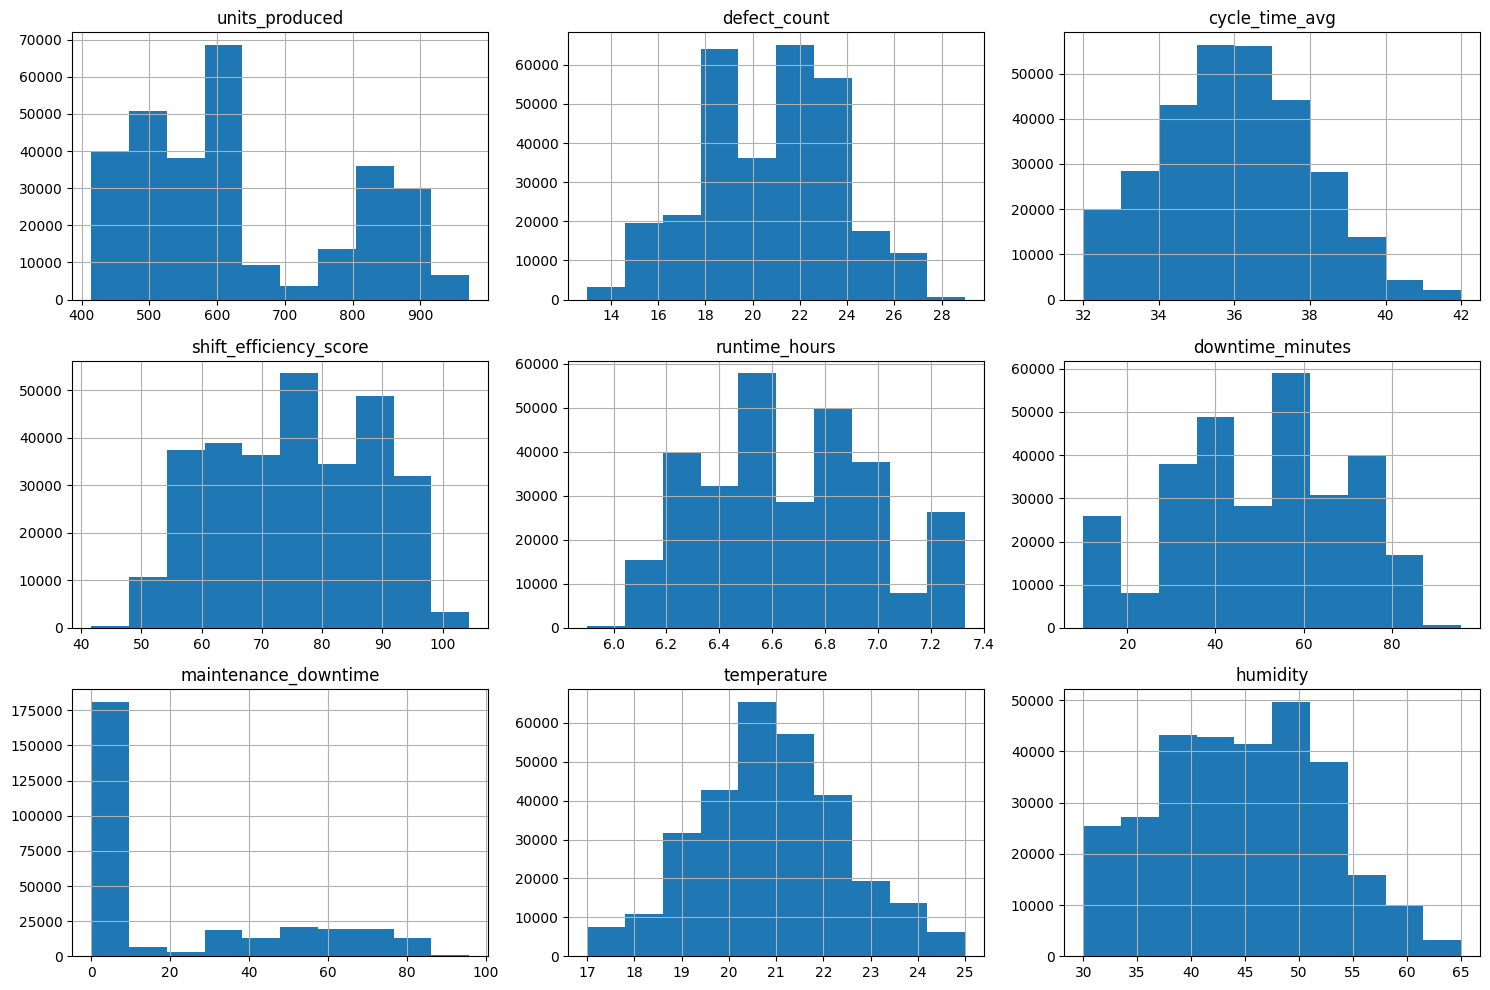

In [136]:
Shift_Data[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

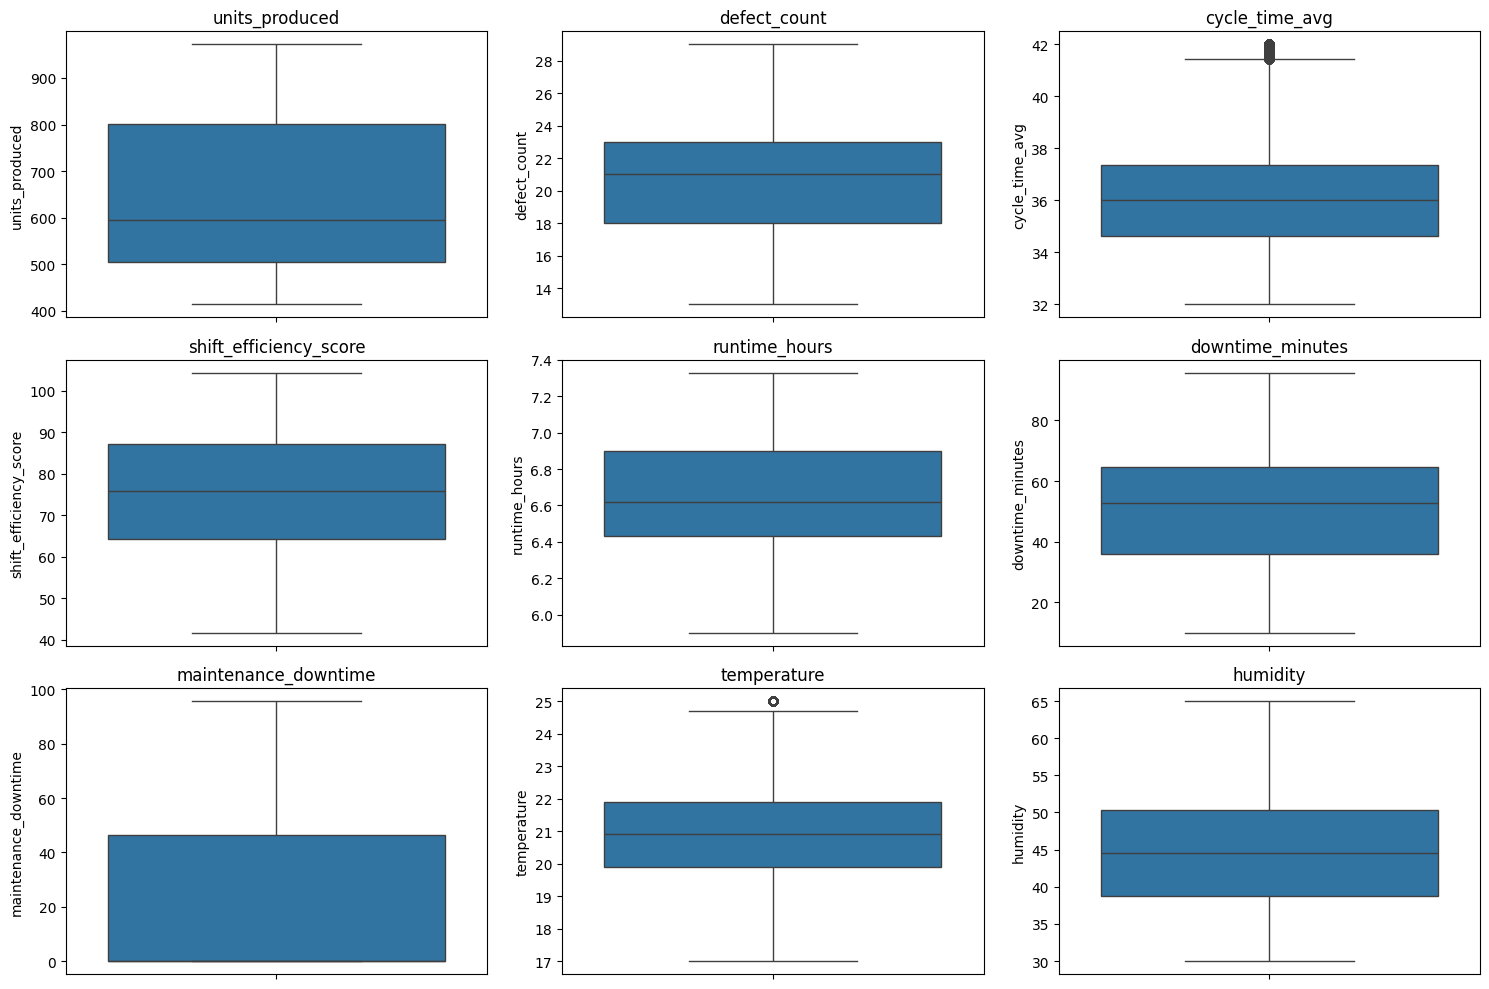

In [137]:
# Using boxplot to check for outliers in dataset

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=Shift_Data[col])
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

## Categorical Variable Analysis

In [138]:
Categorical_cols = ['shift_name', 'issue_type', 'resolved_by', 'machine_status', 'defect_type','inspection_result','severity','experience_level']


for columns in Categorical_cols:
    print(f"Value counts for {columns}:\n")
    print(Shift_Data[columns].value_counts())

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:

resolved_by
No maintainer    181103
TECH_03           12537
TECH_07           12427
TECH_08           12290
TECH_02           12065
TECH_10           11977
TECH_05           11743
TECH_04           11275
TECH_01           10522
TECH_09           10441
TECH_06            9954
Name: count, dtype: int64
Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for inspection_result:

inspection_result

C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1067592903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[i])
C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1067592903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[i])
C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1067592903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[i])
C:\U

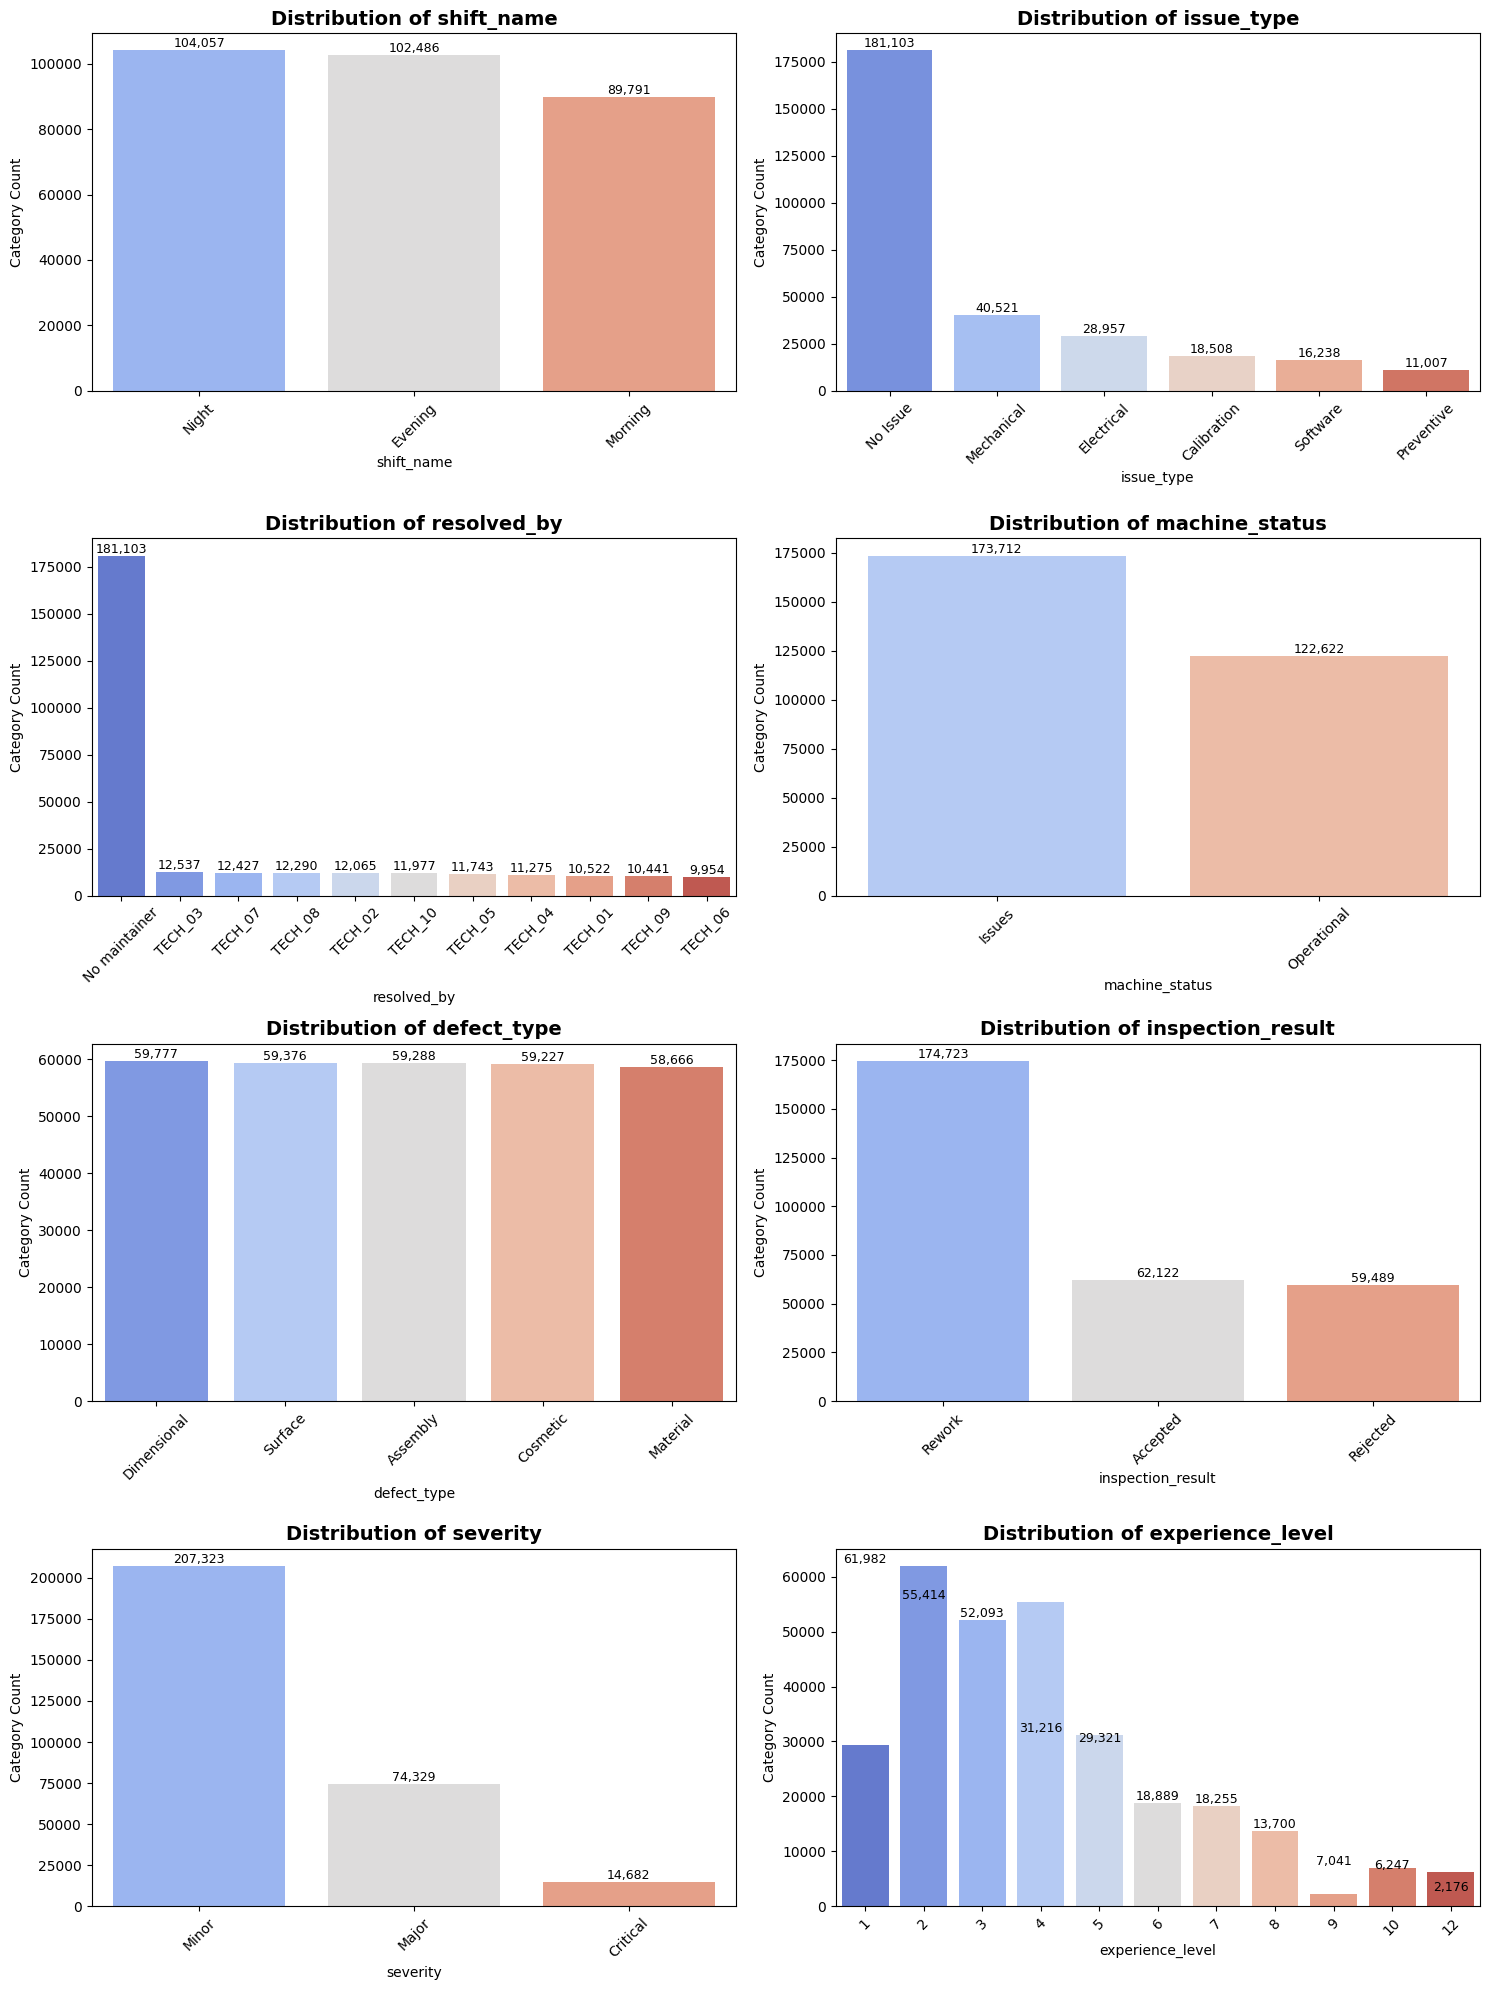

In [139]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

axes = axes.flatten()

for i, column in enumerate(Categorical_cols):
   counts = Shift_Data[column].value_counts().reset_index()
   counts.columns = [column, 'count']

   sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[i])

   # Customize the plot
   axes[i].tick_params(axis='x', rotation=45)
   axes[i].set_title(f'Distribution of {column}', fontsize=14, fontweight='bold')
   axes[i].set_xlabel(column)
   axes[i].set_ylabel('Category Count')


   # add value labels on top of bars
   for j, v in enumerate(counts['count']):
       axes[i].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Operational Perfromance during maintenace vs No Maintenance

In [140]:
Shift_Data['maintenance_flag'].value_counts(normalize=True)*100

maintenance_flag
0    81.82895
1    18.17105
Name: proportion, dtype: float64

In [141]:
maintenance_data= Shift_Data.groupby('maintenance_flag')[num_cols].mean()

maintenance_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


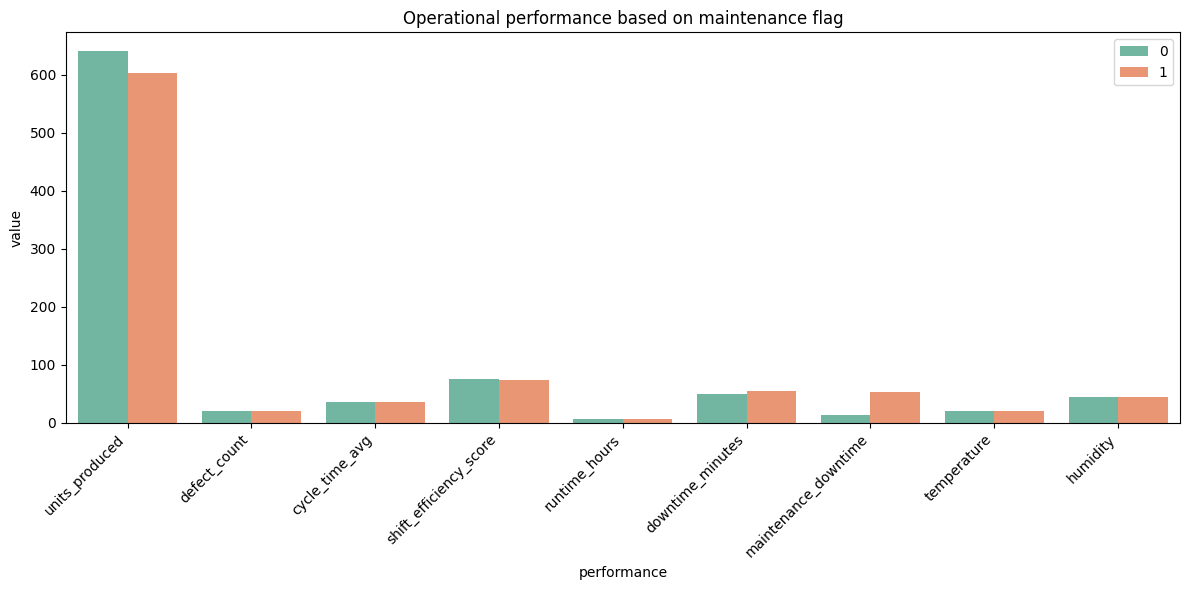

In [142]:
maintenance_data = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_data.melt(
    id_vars=['maintenance_flag'], 
    var_name='performance', 
    value_name = 'value'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data = maintenance_plot_melt,
    x = 'performance',
    y = 'value',
    hue = 'maintenance_flag',
    palette = 'Set2'
)

plt.xticks(rotation=45, ha='right')
plt.title('Operational performance based on maintenance flag')
plt.legend(title='Maintenance Flag')
plt.tight_layout()
plt.legend()


### Shift Performance Analysis

In [143]:
shift_performance_data = Shift_Data.groupby('shift_name').agg({
    "units_produced": ["mean","sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()



shift_performance_data.columns = ['shift_name', 'average_units_produced', 'total_units_produced', 
                                  'average_cycle_time', 'average_defect_count', 'average_downtime_minutes', 
                                  'total_downtime_minutes', 'average_shift_efficiency'
]


# Calculate defect rate
defect_sum = Shift_Data.groupby('shift_name')['defect_count'].sum().values
units_sum =Shift_Data.groupby('shift_name')['units_produced'].sum().values


shift_performance_data['defect_rate'] = (defect_sum / units_sum)*100

shift_performance_data.sort_values(by='average_shift_efficiency', ascending=False)




,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime_minutes,total_downtime_minutes,average_shift_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


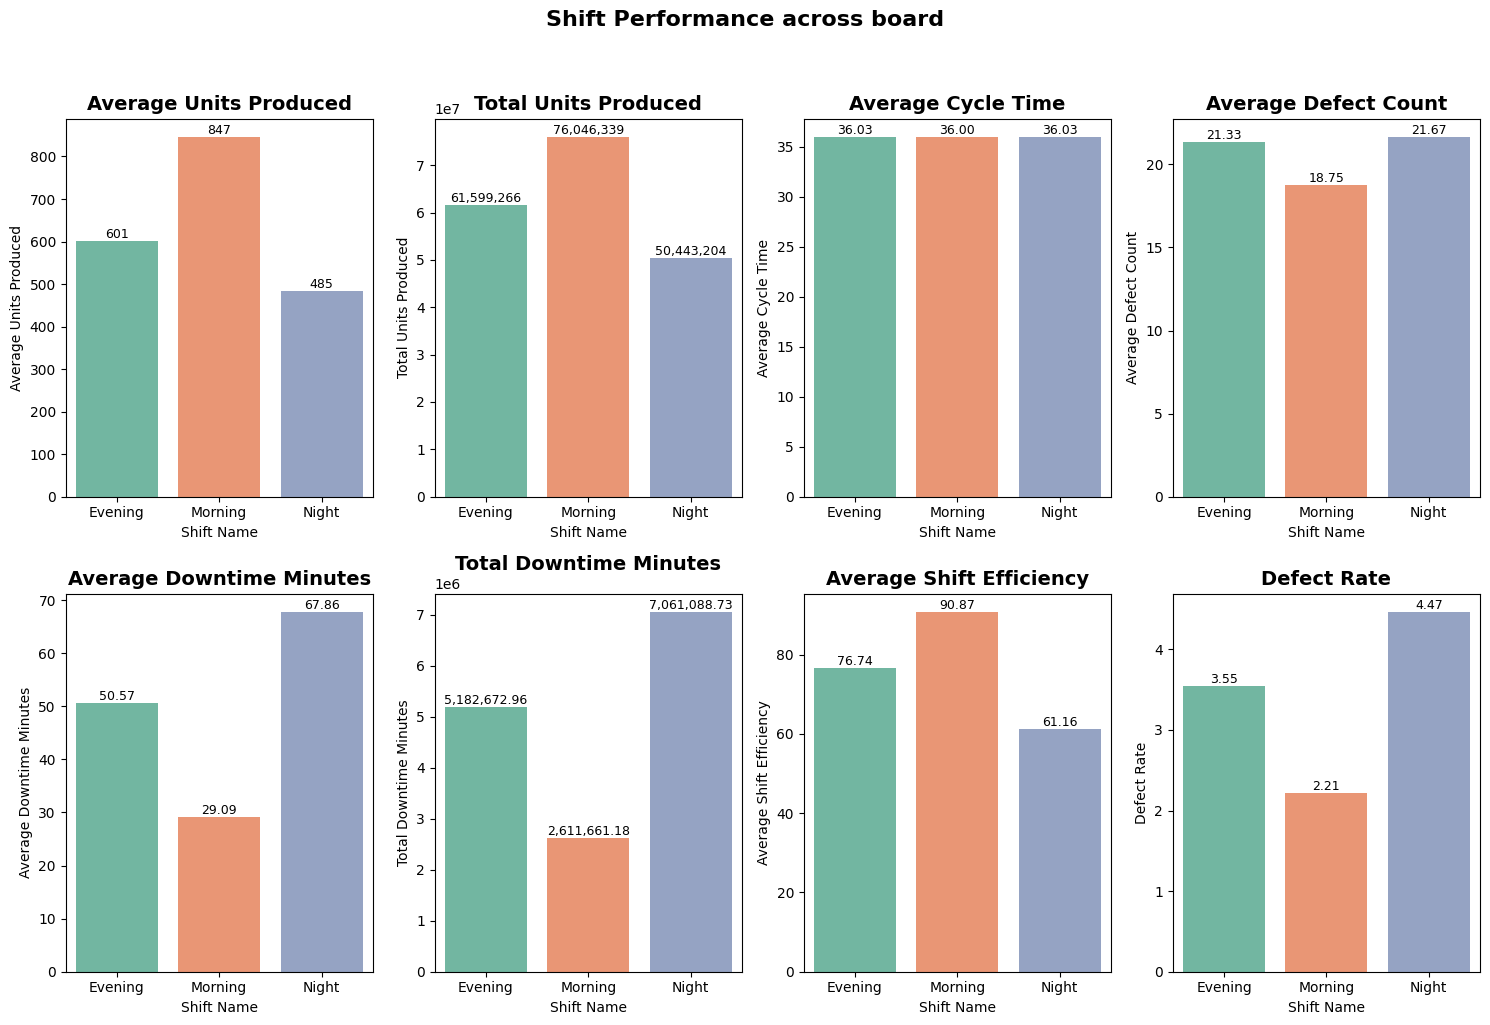

In [144]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

axes = axes.flatten()
metrics = ['average_units_produced', 'total_units_produced', 'average_cycle_time', 'average_defect_count', 'average_downtime_minutes','total_downtime_minutes','average_shift_efficiency','defect_rate']


for i, metric in enumerate(metrics):
    sns.barplot(data=shift_performance_data,
                x = 'shift_name',
                y = metric,
                hue = 'shift_name',
                palette = 'Set2',
                legend = False,
                ax = axes[i])
    
    axes[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Shift Name')
    axes[i].set_ylabel(metric.replace("_", " ").title())


    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
        else:
            axes[i].text(j, v, f'{v:,.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Shift Performance across board', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()  



### Shift Performance based on production ouput per hour

In [145]:
Shift_Data['total_operation_hours'] = Shift_Data["runtime_hours"] + (Shift_Data["downtime_minutes"] / 60)   

output_per_hour = (
    Shift_Data.groupby("shift_name")
    .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())
    .rename("output_per_hour")
)
output_per_hour


C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\1198189190.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

In [146]:
output_per_hour_data = output_per_hour.reset_index()

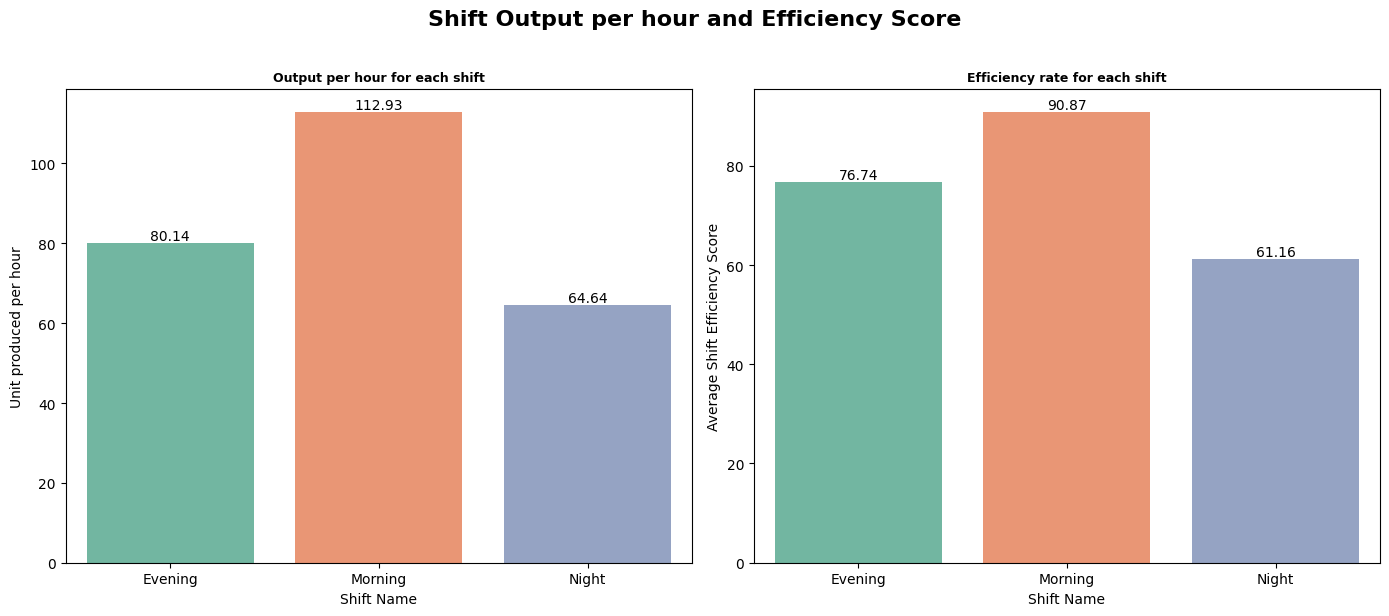

In [147]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))




sns.barplot(
    data = output_per_hour_data,
    x = 'shift_name',
    y = 'output_per_hour',
    hue = 'shift_name',
    palette = 'Set2',
    ax = axes[0],
    legend = False
)



axes[0].set_title('Output per hour for each shift', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Shift Name')
axes[0].set_ylabel('Unit produced per hour')

for i, v in enumerate(output_per_hour_data['output_per_hour']):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')


merged_data = shift_performance_data.merge(output_per_hour_data, on='shift_name')



# plot 2, plotting the shift efficiency score 
sns.barplot(
    data = merged_data,
    x = 'shift_name',
    y = 'average_shift_efficiency',
    hue = 'shift_name',
    palette = 'Set2',
    ax = axes[1],
    legend=False
)



axes[1].set_title('Efficiency rate for each shift', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Shift Name')
axes[1].set_ylabel('Average Shift Efficiency Score')

for i, v in enumerate(merged_data['average_shift_efficiency']):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.suptitle('Shift Output per hour and Efficiency Score', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### OEE Calculation

The code calculates Overall Equipment Effectiveness (OEE) by:

1. **Separating production and machine data** - Creates distinct tables for production metrics (units, defects) and machine metrics (downtime)

2. **Computing three OEE components:**
   - **Availability** - Machine uptime percentage
   - **Performance** - Speed efficiency vs theoretical maximum  
   - **Quality** - Percentage of defect-free units

3. **Tracking monthly trends** - Calculates OEE per month and identifies performance degradation between months

**Why this matters:** OEE is a manufacturing industry standard that pinpoints whether productivity losses come from equipment downtime, slow operation speeds, or product defects.

## A Detailed Breakdown of what is happening:


A simple scenario breakdown of the OEE code and why it is important:

---

## Code Breakdown: A Factory Story

### Meet Our Factory

Imagine you run a **bottle factory**. Each machine should produce **100 bottles per hour** (theoretical rate). Each shift is **7.5 hours** (planned time).

---

### First Code Block: Organizing the Data

**Scenario:** You have a messy notebook with all your factory records mixed together.

```python
prod = (
    df[['production_id', 'shift_id', 'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
    .copy()
)
```

**What's happening:** You create a clean **Production Log** that shows:
- How many bottles were made
- How many were defective
- One entry per production run (no duplicates)

```python
mach = (
    df[['machine_id', 'shift_id', 'date', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)
```

**What's happening:** You create a separate **Maintenance Log** that shows:
- How many minutes each machine broke down
- Organized by machine, shift, and date

**Why separate them?** Because one machine might break down during multiple production runs. Keeping them separate prevents counting the same breakdown twice.

---

### Second Code Block: Calculating OEE (The Scorecard)

**Scenario:** Now you want to grade how well your factory performed each day.

#### Step 1: Calculate Availability (Was the machine running?)

```python
mach['avail_machine'] = 1 - mach['downtime_minutes']/(PLANNED*60)
```

**Simple explanation:** 
- Perfect score = 1.0 (100% available)
- Each minute of breakdown reduces the score

**Example:** 
- Your shift is 7.5 hours = 450 minutes
- Machine broke down for 45 minutes
- Availability = 1 - (45 ÷ 450) = 0.90 or 90%
- **Meaning:** Machine was running 90% of the time

#### Step 2: Calculate Performance (Did it run at full speed?)

```python
merged['performance'] = (merged['units_produced'] / (THEO * PLANNED)).clip(0,1)
```

**Simple explanation:**
- Perfect score = 1.0 (100% speed)
- Slower production reduces the score

**Example:**
- Theoretical speed = 100 bottles per hour
- Planned time = 7.5 hours
- Should have made: 100 × 7.5 = 750 bottles
- Actually made: 600 bottles
- Performance = 600 ÷ 750 = 0.80 or 80%
- **Meaning:** Machine ran at 80% of its target speed

#### Step 3: Calculate Quality (Were the bottles good?)

```python
merged['quality'] = 1 - merged['defect_count']/merged['units_produced']
```

**Simple explanation:**
- Perfect score = 1.0 (100% good products)
- Each defective product reduces the score

**Example:**
- Made 600 bottles
- 30 were cracked (defects)
- Quality = 1 - (30 ÷ 600) = 0.95 or 95%
- **Meaning:** 95% of bottles were good, 5% were defective

#### Step 4: Calculate Final OEE Score

```python
merged['oee_est'] = merged['availability'] * merged['performance'] * merged['quality']
```

**Example calculation:**
- Availability = 90% (0.90)
- Performance = 80% (0.80)
- Quality = 95% (0.95)

**OEE = 0.90 × 0.80 × 0.95 = 0.684 or 68.4%**

**What this means for the factory owner:**

| Score | Grade | What It Tells You |
|-------|-------|-------------------|
| 68.4% | C | You're losing 31.6% of potential production |
| | | - 10% lost to breakdowns |
| | | - 20% lost to slow speed |
| | | - 5% lost to defects |

---

### Monthly Tracking: Spotting Problems Early

```python
monthly_oee = merged.groupby('month')['oee_est'].mean()
```

**Scenario:** You track OEE for three months:

| Month | OEE | Change |
|-------|-----|--------|
| Month 1 | 75% | Starting point |
| Month 2 | 70% | ↓ 5% |
| Month 3 | 65% | ↓ 10% total |

```python
degradation = (m1 - m3) / m1 * 100
```

**Result:** 13.3% degradation

**What this tells you:** Something is getting worse over time. Machines might be aging, maintenance might be slipping, or operators might be struggling.

---

### The Big Picture: Why This Matters

**Without OEE:** "Our factory isn't producing enough" (vague problem)

**With OEE:** 
- "Availability is 90%" → Breakdowns are minimal ✓
- "Performance is 60%" → Machines running too slow ✗
- "Quality is 95%" → Defects are fine ✓

**Action Plan:** Focus on improving machine speed (performance), not breakdowns or quality.

---

### Summary Table

| OEE Component | Question It Answers | Example Problem |
|---------------|---------------------|-----------------|
| **Availability** | Was the machine running? | Breakdowns, changeovers |
| **Performance** | Was it running at full speed? | Slow operation, jams |
| **Quality** | Did it make good products? | Defects, scrap |
| **OEE** | Overall factory health? | Combined score |

**Perfect Factory (100% OEE):** 
- Machine never stops (100% availability)
- Always runs at full speed (100% performance)
- Every product is perfect (100% quality)

**Real World:** Most factories score 60-85%. The code helps you find exactly where you're losing points.

In [148]:
production = (
    Shift_Data[["production_id", "shift_id", "date", "units_produced", "defect_count"]]
    .drop_duplicates(subset=['production_id'])
    .copy()

)

machine = (
    Shift_Data[["machine_id", "shift_id", "date", "downtime_minutes"]]
    .drop_duplicates()
    .copy()
)

In [149]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [150]:
machine.head()

,machine_id,shift_id,date,downtime_minutes
0,MC_001,1,2024-01-01,15.39
2308,MC_002,3,2024-01-01,53.73
2309,MC_003,3,2024-01-01,51.90
2331,MC_004,3,2024-01-01,54.45
2281,MC_001,3,2024-01-01,52.99


### OEE Metric Calculation

In [151]:
import os 

PLANNED = globals().get('PLANNED_H',7.5)
THEO = globals().get('THEO_RATE',100.0)

# compute per machine availability 

machine['available_machine'] = 1- machine['downtime_minutes'] / (PLANNED * 60)
machine['available_machine'] = machine['available_machine'].clip(0,1)



available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean()
    .reset_index()
    .rename(columns={'available_machine': 'machine_availability'})
)

In [152]:
available_machine_agg.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


In [153]:
available_machine_agg.shape

(273, 3)

In [154]:
# merging availability and production 

merged_production_data = production.merge(available_machine_agg, how='left', on=['date', 'shift_id'])   
merged_production_data['machine_availability'] = merged_production_data['machine_availability'].fillna(1)

# Performance based on the planned time 
merged_production_data['performance'] = (merged_production_data['units_produced'] / (THEO * PLANNED)).clip(0,1)

# Quality
merged_production_data['quality'] = 1 - merged_production_data["defect_count"] / merged_production_data["units_produced"]
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0,1)

# Final OEE estimate

merged_production_data['oee_est'] = merged_production_data['machine_availability'] * merged_production_data['performance']

# based on months 
merged_production_data['month'] = merged_production_data['date'].dt.month

In [155]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.963687,1
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.623143,1
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.574938,1
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.619616,1
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.652537,1


In [156]:
# monthly OEE(overall equipment effective for each of the month)

monthly_oee = (

    merged_production_data.groupby('month')['oee_est']
    .mean()
    .sort_index()
)

# print to confirm it matches the earlier value
for month, value in monthly_oee.items():
    print(f"Month {month} OEE: {value*100:.2f}%")


Month 1 OEE: 77.35%
Month 2 OEE: 70.76%
Month 3 OEE: 71.07%


In [157]:
if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degradation = (m1-m3) / m1 * 100
    print(f"Quaterly degradation (month 1 -> month 3 ): {degradation:.2f}")
else:
    print('could not find month 1 and 3 in the data to compute the degradation process or curve ')



Quaterly degradation (month 1 -> month 3 ): 8.12


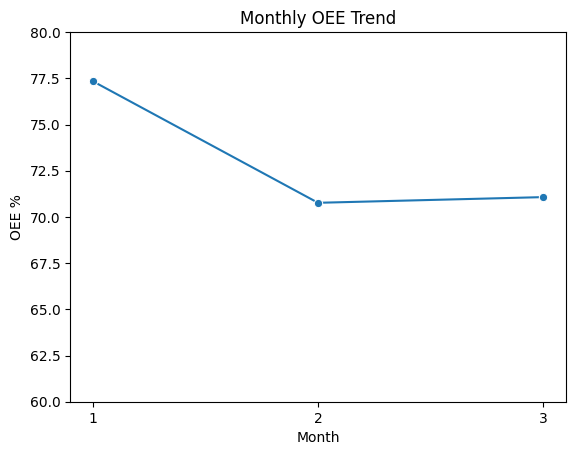

In [158]:
monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df["OEE_percentage"] = monthly_oee_df['oee_est'] * 100


sns.lineplot(x = 'month', y='OEE_percentage', data = monthly_oee_df, marker ='o')
plt.title("Monthly OEE Trend")
plt.ylabel('OEE %')
plt.ylim(60, 80)
plt.xticks([1, 2, 3])
plt.xlabel('Month')
plt.show()


### Experience vs the defect counts that occured during production

C:\Users\Omabo\AppData\Local\Temp\ipykernel_49648\3095379806.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = Shift_Data, x='experience_level', y='defect_count', palette = 'Set2')


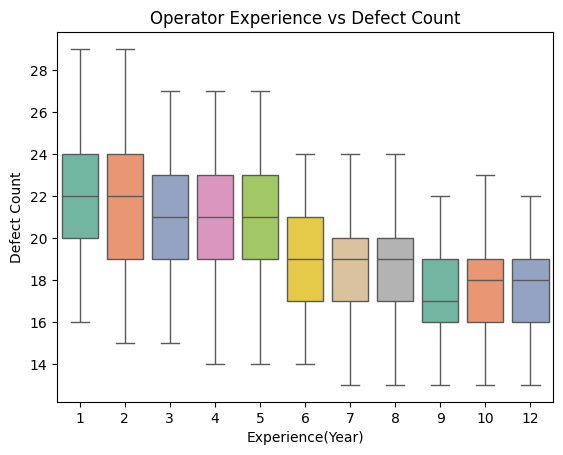

In [159]:
sns.boxplot(data = Shift_Data, x='experience_level', y='defect_count', palette = 'Set2')
plt.title('Operator Experience vs Defect Count')
plt.xlabel('Experience(Year)')
plt.ylabel('Defect Count')
plt.show()



git add . 
git commit -m "eda shift performance completed. "
git branch
git push origin main

### Feature Engineering

In [160]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [161]:
# Engineering new features

mask = Shift_Data['end_time'] < Shift_Data['start_time']
Shift_Data.loc[mask, 'end_time'] = Shift_Data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

# Shift Duration
Shift_Data['shift_duration'] = (Shift_Data['end_time'] - Shift_Data['start_time']).dt.total_seconds()/ 3600

# Defect rate
Shift_Data['defect_rate'] = Shift_Data['defect_count'] / Shift_Data['units_produced'].replace(0,pd.NA)

Shift_Data['downtime_ratio'] = Shift_Data['downtime_minutes'] / (Shift_Data['shift_duration'] * 60)

# temporal feature
Shift_Data['day_of_week'] = Shift_Data['date'].dt.dayofweek
Shift_Data['hour_of_day'] = Shift_Data['start_time'].dt.hour

In [162]:
Shift_Data.shape

(296334, 36)

In [163]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [164]:
# drop identifiers, leakage and raw datetime columns 

columns_to_drop =[
    #identifier
    'shift_id','operator_id','operator_name','machine_id','production_id', 
    # leakage
    'qc_id','resolved_by','timestamp',
    # raw datetime columns
    'start_time', 'end_time','date'
]

Shift_Data.drop(columns = columns_to_drop, inplace = True )

In [165]:
Shift_Data.columns

Index(['shift_name', 'supervisor_id', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'experience_level',
       'skill_category', 'runtime_hours', 'downtime_minutes',
       'maintenance_flag', 'machine_status', 'issue_type',
       'maintenance_downtime', 'defect_type', 'severity', 'inspection_result',
       'temperature', 'humidity', 'total_operation_hours', 'shift_duration',
       'defect_rate', 'downtime_ratio', 'day_of_week', 'hour_of_day'],
      dtype='object')

In [166]:
Shift_Data.duplicated().sum()

np.int64(119015)

In [167]:
Shift_Data.drop_duplicates(inplace=True)

In [168]:
Shift_Data.duplicated().sum()

np.int64(0)

In [169]:
Shift_Data.head()

,shift_name,supervisor_id,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,...,severity,inspection_result,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,SUP_01,929,20,35.65,95.945255,7,Expert,7.24,15.39,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,SUP_03,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [170]:
Shift_Data['shift_efficiency_score'].describe()

count    177319.000000
mean         75.829886
std          12.955768
min          41.690033
25%          64.595342
50%          76.253965
75%          87.578778
max         104.379285
Name: shift_efficiency_score, dtype: float64

In [171]:
Shift_Data.drop(['supervisor_id', 'inspection_result'], axis= 1)

,shift_name,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,...,defect_type,severity,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,929,20,35.65,95.945255,7,Expert,7.24,15.39,0,...,Material,Minor,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,0,...,Surface,Minor,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Cosmetic,Major,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Dimensional,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Assembly,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294252,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Assembly,Minor,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294254,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Dimensional,Major,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294256,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Cosmetic,Major,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294257,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Material,Minor,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14


### Dimensionality check

In [172]:
# Checking for dependent features to reduce redundancy between specific columns before modelling


column_pairs = [
    ('downtime_minutes', 'downtime_ratio'),       
    ('defect_count', 'defect_rate'),               
    ('runtime_hours', 'total_operation_hours'),   
    ('maintenance_downtime', 'downtime_minutes'),  
    ('shift_duration', 'runtime_hours'),
]           

for col1, col2 in column_pairs:
    if col1 in Shift_Data.columns and col2 in Shift_Data.columns:
        r = Shift_Data[col1].corr(Shift_Data[col2])
        print(f"{col1} vs {col2}: r = {r:.3f}")

downtime_minutes vs downtime_ratio: r = 1.000
defect_count vs defect_rate: r = 0.737
runtime_hours vs total_operation_hours: r = -0.051
maintenance_downtime vs downtime_minutes: r = 0.100
shift_duration vs runtime_hours: r = nan


c:\Users\Omabo\OneDrive\Desktop\Shift-Ops-Optimizer-\shiftops_environ\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Omabo\OneDrive\Desktop\Shift-Ops-Optimizer-\shiftops_environ\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [173]:
# drop down_time minutes to based on redundancy score 

Shift_Data.drop(columns=['downtime_minutes','defect_count'], inplace=True)

## Modelling Phase 
### Data splitting 

In [174]:
x = Shift_Data.drop(columns=['shift_efficiency_score'])
y =  Shift_Data['shift_efficiency_score']

In [175]:
x.head()

,shift_name,supervisor_id,units_produced,cycle_time_avg,experience_level,skill_category,runtime_hours,maintenance_flag,machine_status,issue_type,...,severity,inspection_result,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,SUP_01,929,35.65,7,Expert,7.24,0,Operational,No Issue,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,SUP_03,530,35.61,5,Intermediate,6.60,0,Issues,No Issue,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,SUP_03,489,34.01,2,Junior,6.64,0,Issues,No Issue,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,SUP_03,489,34.01,2,Junior,6.64,0,Issues,No Issue,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,SUP_03,489,34.01,2,Junior,6.64,0,Issues,No Issue,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [176]:
# Splitting data into training and testing 


from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test =train_test_split(x, y, test_size = 0.2, random_state = 42)



In [177]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(141855, 22)
(35464, 22)
(141855,)
(35464,)


In [178]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177319 entries, 0 to 294258
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_name              177319 non-null  object 
 1   supervisor_id           177319 non-null  object 
 2   units_produced          177319 non-null  int64  
 3   cycle_time_avg          177319 non-null  float64
 4   shift_efficiency_score  177319 non-null  float64
 5   experience_level        177319 non-null  int64  
 6   skill_category          177319 non-null  object 
 7   runtime_hours           177319 non-null  float64
 8   maintenance_flag        177319 non-null  int64  
 9   machine_status          177319 non-null  object 
 10  issue_type              177319 non-null  object 
 11  maintenance_downtime    177319 non-null  float64
 12  defect_type             177319 non-null  object 
 13  severity                177319 non-null  object 
 14  inspection_result       1

In [179]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Numerical_features = ['units_produced','cycle_time_avg','experience_level','runtime_hours','maintenance_flag', 
                      'maintenance_downtime','temperature','humidity', 'total_operation_hours',
                        'shift_duration','defect_rate', 'downtime_ratio', 'day_of_week', 'hour_of_day']



Categorical_features = ['shift_name', 'skill_category', 'machine_status', 
                        'issue_type', 'defect_type', 'severity']


preprocess = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), Categorical_features),
        ('num', 'passthrough', Numerical_features)
    ]
)

In [180]:

import mlflow
import mlflow.sklearn


import dagshub
dagshub.init(repo_owner='omaboeniinarku', repo_name='Shift-Ops-Optimizer-', mlflow=True)

from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


models = {
    'LinearRegressionModel': LinearRegression(),
    'GradientBoosting': GradientBoostingRegressor(),
    'RandomForest': RandomForestRegressor()

}


result ={}
fitted_pipeline = {}

mlflow.set_experiment("Shift_Optimization_Models")

for name, model in models.items():

    with mlflow.start_run(run_name = name):

        # creating the pipeline
        pipeline = Pipeline(steps=[
            ('pre_process', preprocess),
            ('ml_model', model)
        ])

        # Training the models on the train data
        pipeline.fit(x_train, y_train)
        # getting the models to predict the test data
        y_pred = pipeline.predict(x_test)

        # Defining metrics 
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
       

        result[name] = {"r2": r2, "mae": mae, "mse":mse}

        fitted_pipeline[name] = pipeline
         
        # Mlflow logging
        mlflow.log_param('model_name', name)
        mlflow.log_metric('r2', r2)
        mlflow.log_metric('mae', mae)
        mlflow.log_metric('mse', mse)
       

        mlflow.sklearn.log_model(pipeline, artifact_path ='model')

        print(f"{name} -> R2: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}")

         
         


         




Initialized MLflow to track repo "omaboeniinarku/Shift-Ops-Optimizer-"

Repository omaboeniinarku/Shift-Ops-Optimizer- initialized!

2026/06/05 06:52:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 06:52:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearRegressionModel -> R2: 0.9358, MAE: 2.6097, MSE: 10.7945
🏃 View run LinearRegressionModel at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0/runs/3f935bb593fb4786bc2913221e49b96d
🧪 View experiment at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0


2026/06/05 06:53:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 06:53:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting -> R2: 0.9486, MAE: 2.3359, MSE: 8.6482
🏃 View run GradientBoosting at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0/runs/d434bbace62d479085fdf2d8e45ebbc3
🧪 View experiment at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0


2026/06/05 06:55:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 06:55:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest -> R2: 1.0000, MAE: 0.0026, MSE: 0.0003
🏃 View run RandomForest at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0/runs/14a9a0bedd8e4e9db4ec63a8553cbfd4
🧪 View experiment at: https://dagshub.com/omaboeniinarku/Shift-Ops-Optimizer-.mlflow/#/experiments/0
